# Key Moment Detection: Does the LLM Find What Humans Find?

## What are key moments?

In a K-12 math tutoring session, there are moments where the tutor makes a pedagogical choice that meaningfully shapes the student's learning. We study two types:

**Scaffolding/Rigor moments** arise when the tutor must decide how much support to provide. Scaffolding is temporary, calibrated support that helps a student accomplish a task they cannot yet do independently — breaking problems into steps, hinting toward answers, modeling worked examples. Rigor means maintaining cognitive demand — requiring explanations, extending problems, fading support. The core tradeoff: too much support robs the student of productive struggle; too little leaves them floundering. A key moment occurs when this choice is notably well-calibrated, miscalibrated, or when the student's signal creates a genuine fork in how to proceed.

**Rapport moments** arise when the tutor's interpersonal choices shape the learning environment. Rapport includes trust and safety (the student feels comfortable making mistakes), genuine interest (the tutor engages with the student as a person), emotional attunement (noticing and responding to frustration, excitement, fatigue), and relational continuity (remembering details across sessions). A key moment occurs when the tutor builds, misses, or damages rapport — including missed opportunities where the tutor ignores an emotional signal or handles a personal moment superficially.

Human expert annotators watch tutoring transcripts and mark these moments as turn ranges (e.g., turns 45-62), identifying both the type (scaffolding or rapport) and the effectiveness of the tutor's response.

**The question**: can an LLM find the same moments that human experts find?

## The dataset

Our dataset contains **201 tutoring transcripts** with **291 annotation passes** (one pass = one annotator labeling one transcript for one type). These 291 passes produced **1,688 individual moment annotations**. Most transcripts were annotated once; 54 received multiple passes (different annotators, or both types). Nine annotators contributed, grouped into three calibration profiles by labeling tendency (generous, balanced, demanding). Six transcripts used as few-shot examples in the LLM prompts are excluded from all evaluation, leaving **195 transcripts** for analysis.

## How we measure overlap

We use **Intersection over Union (IoU)**: if a human marked turns 45-62 and the LLM marked turns 43-60, IoU measures how much those ranges overlap relative to their combined span. We count a **match** when IoU >= 0.3 (at least 30% overlap). Before comparing, we merge overlapping human annotations into **clusters** — when multiple annotators flag the same event with slightly different boundaries.

## Train vs. held-out

- **Train** (98 transcripts): the prompts were iterated using error examples from these
- **Held-out** (97 transcripts): the prompts have never seen these

All results use **v5 prompts** (our best and final detection prompts).

In [25]:
import sys
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict, Counter

warnings.filterwarnings('ignore', category=FutureWarning)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'validation' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from annotator.core.utils import (
    load_ground_truth, compute_iou, merge_overlapping_ranges,
    EXAMPLE_CONV_IDS, RESULTS_DIR, IOU_THRESHOLD,
)
from annotator.eval.eval import (
    compute_detection_metrics, compute_effectiveness_metrics,
    compute_human_ceiling, match_for_effectiveness, match_gold_direct,
    filter_moments_by_type, filter_matches_by_type,
    load_detections_as_moments, load_annotations,
    ANNOTATION_TYPES, EFFECTIVENESS_LABELS,
    cohens_kappa,
)

%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (10, 6), 'figure.dpi': 100,
    'savefig.dpi': 300, 'savefig.bbox': 'tight', 'font.family': 'sans-serif',
})
FIGURES_DIR = REPO_ROOT / 'validation' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    'matched': '#2ecc71', 'human_only': '#3498db', 'llm_only': '#e67e22',
    'scaffolding': '#2980b9', 'rapport': '#e74c3c',
    'primary': '#2c3e50', 'secondary': '#7f8c8d',
    'llm': '#2980b9', 'human_ceiling': '#e74c3c',
}

In [26]:
# All results use v5 prompts. IoU threshold is 0.3 everywhere.
VERSION = 'v5'
GOLD_VERSION = 'v5_gold'
IOU = 0.3  # same threshold for ALL matching (detection, effectiveness, ceiling)

ground_truth = load_ground_truth()

# Identify dev vs held-out by checking which conversations were in v4 (the dev pipeline)
_v4_det = load_detections_as_moments('v4')
_v4_ids = set(_v4_det.keys()) if _v4_det else set()

v5_det = load_detections_as_moments(VERSION)
if v5_det is None:
    raise FileNotFoundError(f'No detections.json for {VERSION}')

all_eval_ids = set(ground_truth['conversations'].keys()) & set(v5_det.keys()) - EXAMPLE_CONV_IDS
train_ids = all_eval_ids & _v4_ids
ho_ids = all_eval_ids - _v4_ids

# Type-filter LLM detections per conversation
gt_by_conv = {}
for cid in all_eval_ids:
    hm = ground_truth['conversations'][cid]['key_moments']
    ht = {m.get('annotation_type') for m in hm}
    gt_by_conv[cid] = hm
    v5_det[cid] = [m for m in v5_det[cid] if m.get('annotation_type') in ht]

print(f'Pipeline version: {VERSION} (all results use v5 prompts)')
print(f'IoU threshold:    {IOU} (same for detection, effectiveness matching, and ceiling)')
print(f'Train set:          {len(train_ids)} conversations (used during prompt iteration)')
print(f'Held-out set:     {len(ho_ids)} conversations (prompts never saw these)')
print(f'Total:            {len(all_eval_ids)} conversations')

Pipeline version: v5 (all results use v5 prompts)
IoU threshold:    0.3 (same for detection, effectiveness matching, and ceiling)
Train set:          98 conversations (used during prompt iteration)
Held-out set:     97 conversations (prompts never saw these)
Total:            195 conversations


## Detection Results

| Metric | What it measures |
|---|---|
| **Cluster Recall** | What fraction of human moment clusters did the LLM find? |
| **Moment Precision** | What fraction of LLM detections match a human cluster? |
| **Mean IoU** | Average overlap quality of matched pairs |

In [27]:
results = []
for label, ids in [('Train', train_ids), ('Held-out', ho_ids), ('Combined', all_eval_ids)]:
    gt_sub = {c: gt_by_conv[c] for c in ids}
    llm_sub = {c: v5_det.get(c, []) for c in ids}
    m = compute_detection_metrics(gt_sub, llm_sub, iou_threshold=IOU)
    results.append({
        '': label,
        'Conversations': len(ids),
        'Human Clusters': m['total_human_clusters'],
        'LLM Detections': m['total_llm_annotations'],
        'Cluster Recall': f"{m['cluster_recall']:.1%}",
        'Moment Precision': f"{m['moment_precision']:.1%}",
        'Mean IoU': f"{m['mean_iou']:.3f}",
    })

df = pd.DataFrame(results).set_index('')
print(f'v5 Detection Performance (IoU >= {IOU})\n')
df

v5 Detection Performance (IoU >= 0.3)



,Conversations,Human Clusters,LLM Detections,Cluster Recall,Moment Precision,Mean IoU
,,,,,,
Train,98,586,828,55.1%,40.7%,0.673
Held-out,97,524,863,58.6%,35.5%,0.693
Combined,195,1110,1691,56.8%,38.0%,0.683


### By Annotation Type

Scaffolding/rigor moments and rapport moments may have different detection difficulty — scaffolding events often have clearer textual signals (errors, corrections) while rapport moments can be subtler (tone, missed opportunities).

In [28]:
gt_all = {c: gt_by_conv[c] for c in all_eval_ids}
llm_all = {c: v5_det.get(c, []) for c in all_eval_ids}

type_results = []
for ann_type in ANNOTATION_TYPES:
    gt_typed = filter_moments_by_type(gt_all, ann_type)
    llm_typed = filter_moments_by_type(llm_all, ann_type)
    m = compute_detection_metrics(gt_typed, llm_typed, iou_threshold=IOU)
    if m['total_human_clusters'] > 0:
        type_results.append({
            '': ann_type.title(),
            'Clusters': m['total_human_clusters'],
            'LLM Dets': m['total_llm_annotations'],
            'Recall': f"{m['cluster_recall']:.1%}",
            'Precision': f"{m['moment_precision']:.1%}",
            'Mean IoU': f"{m['mean_iou']:.3f}",
        })

# Combined row
m_all = compute_detection_metrics(gt_all, llm_all, iou_threshold=IOU)
type_results.append({
    '': 'Combined',
    'Clusters': m_all['total_human_clusters'],
    'LLM Dets': m_all['total_llm_annotations'],
    'Recall': f"{m_all['cluster_recall']:.1%}",
    'Precision': f"{m_all['moment_precision']:.1%}",
    'Mean IoU': f"{m_all['mean_iou']:.3f}",
})

df_type = pd.DataFrame(type_results).set_index('')
print(f'Detection by Annotation Type (IoU >= {IOU}, all {len(all_eval_ids)} transcripts)\n')
df_type

Detection by Annotation Type (IoU >= 0.3, all 195 transcripts)



,Clusters,LLM Dets,Recall,Precision,Mean IoU
,,,,,
Scaffolding,590,878,59.8%,41.3%,0.679
Rapport,520,813,53.3%,34.4%,0.687
Combined,1110,1691,56.8%,38.0%,0.683


## IoU Sensitivity

Do the matches barely clear the 0.3 threshold, or do they represent real overlap? We recompute recall at stricter thresholds. Smooth degradation = genuine matches. Cliff-drop = noise.

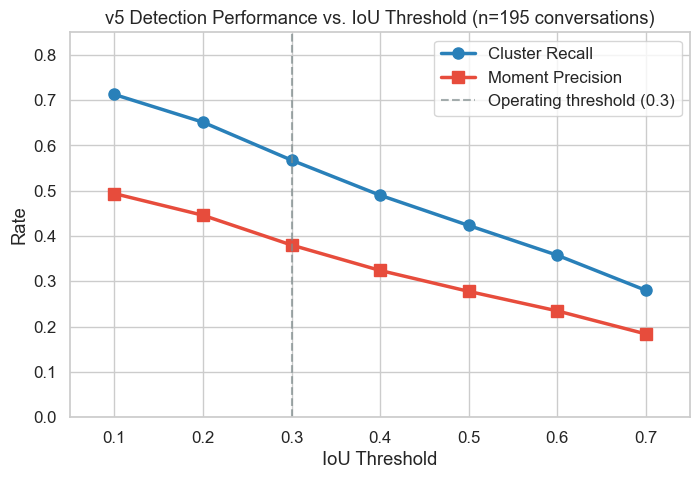

,IoU,Recall,Precision
0,0.1,71.3%,49.4%
1,0.2,65.1%,44.6%
2,0.3,56.8%,38.0%
3,0.4,49.0%,32.4%
4,0.5,42.3%,27.8%
5,0.6,35.8%,23.5%
6,0.7,28.0%,18.4%


In [29]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
gt_all = {c: gt_by_conv[c] for c in all_eval_ids}
llm_all = {c: v5_det.get(c, []) for c in all_eval_ids}

sens = []
for t in thresholds:
    m = compute_detection_metrics(gt_all, llm_all, iou_threshold=t)
    sens.append({'IoU': t, 'Recall': m['cluster_recall'], 'Precision': m['moment_precision']})

df_sens = pd.DataFrame(sens)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_sens['IoU'], df_sens['Recall'],
        'o-', color=COLORS['scaffolding'], linewidth=2.5, markersize=8, label='Cluster Recall')
ax.plot(df_sens['IoU'], df_sens['Precision'],
        's-', color=COLORS['rapport'], linewidth=2.5, markersize=8, label='Moment Precision')
ax.axvline(x=IOU, color=COLORS['secondary'], linestyle='--', alpha=0.7,
           label=f'Operating threshold ({IOU})')
ax.set_xlabel('IoU Threshold')
ax.set_ylabel('Rate')
ax.set_title(f'v5 Detection Performance vs. IoU Threshold (n={len(all_eval_ids)} conversations)')
ax.legend(loc='upper right')
ax.set_ylim(0, 0.85)
ax.set_xlim(0.05, 0.75)
fig.savefig(FIGURES_DIR / 'iou_sensitivity.png')
fig.savefig(FIGURES_DIR / 'iou_sensitivity.pdf')
plt.show()

# Table
df_disp = df_sens.copy()
df_disp['Recall'] = df_disp['Recall'].map('{:.1%}'.format)
df_disp['Precision'] = df_disp['Precision'].map('{:.1%}'.format)
df_disp

## Overlap Visualization

What do matches and misses look like? Each row shows one conversation: human clusters on top, LLM detections on bottom. Green = matched (IoU >= 0.3), blue = human only (miss), orange = LLM only (false positive).

Five conversations shown, spanning low to high recall.

C:\Users\azhang\AppData\Local\Temp\ipykernel_28976\2896443648.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


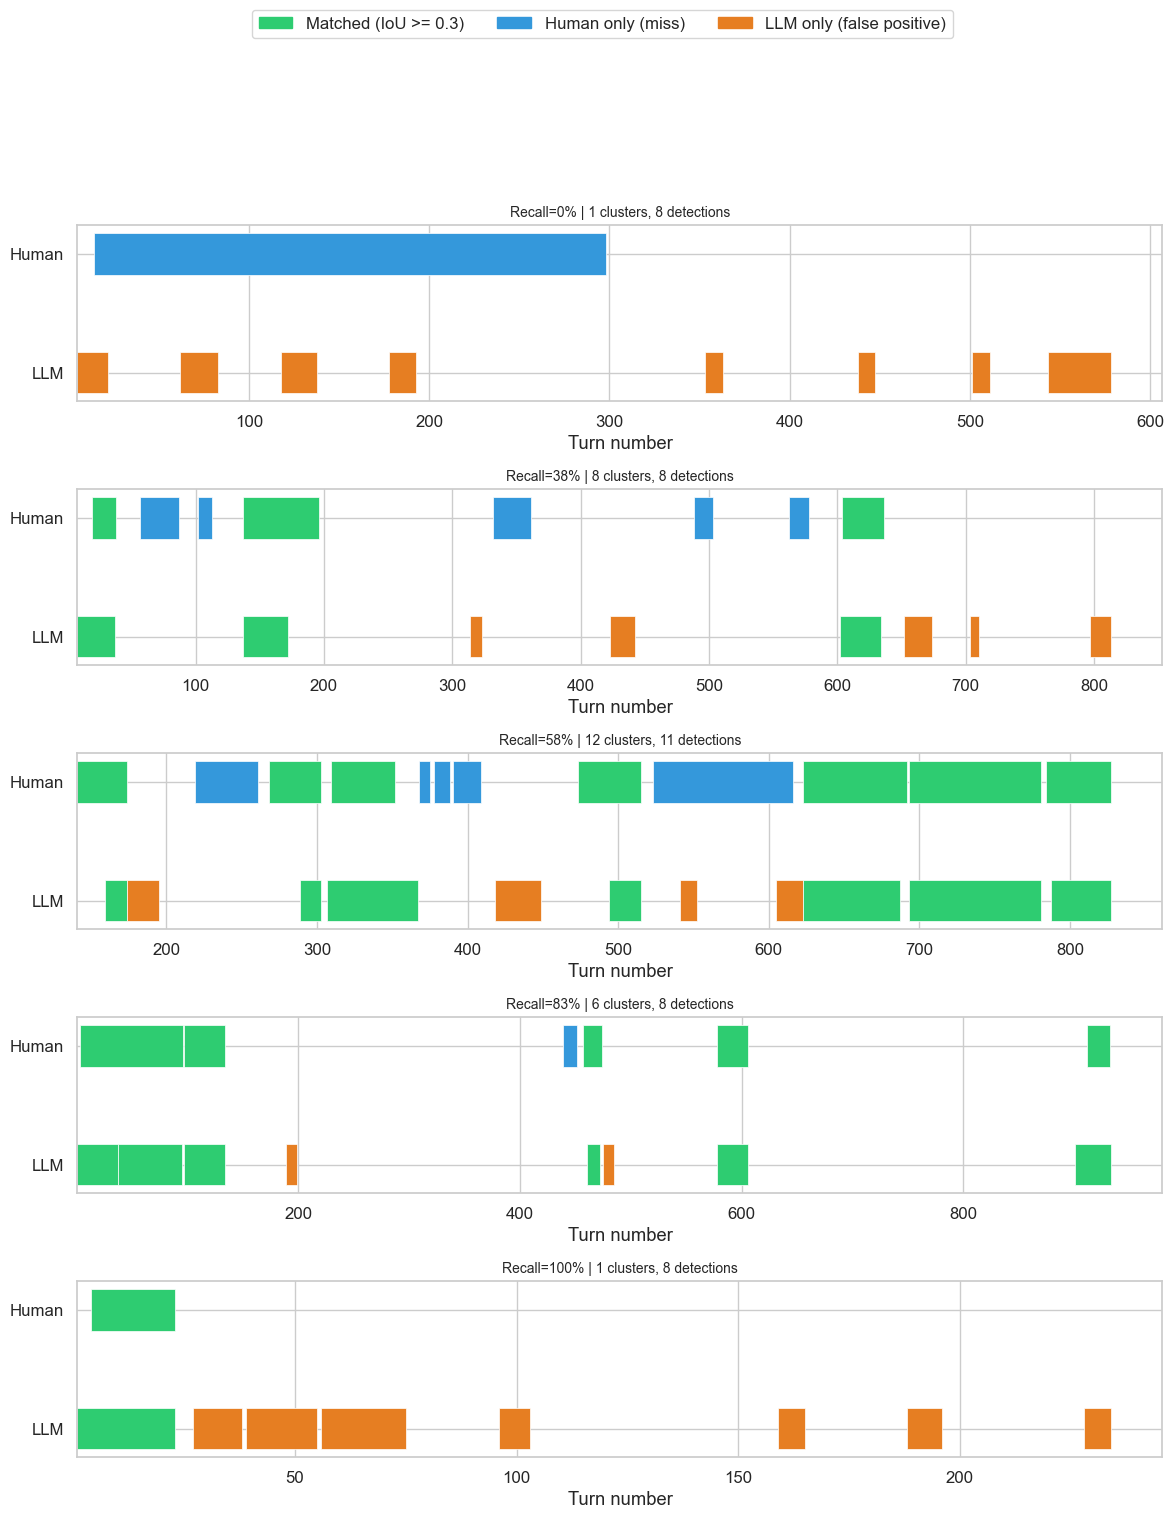

In [30]:
gt_dev = {c: gt_by_conv[c] for c in train_ids}
llm_dev = {c: v5_det.get(c, []) for c in train_ids}
metrics_dev = compute_detection_metrics(gt_dev, llm_dev, iou_threshold=IOU)
per_conv = metrics_dev['per_conversation']
with_clusters = {cid: v for cid, v in per_conv.items() if v['clusters'] > 0}
sorted_recalls = sorted(with_clusters.items(), key=lambda x: x[1]['recall'])

n = len(sorted_recalls)
selected = [sorted_recalls[i] for i in [0, n//4, n//2, 3*n//4, n-1]]

fig, axes = plt.subplots(len(selected), 1, figsize=(14, 3.2 * len(selected)),
                         gridspec_kw={'hspace': 0.5})
for ax, (conv_id, conv_m) in zip(axes, selected):
    human_raw = gt_by_conv.get(conv_id, [])
    llm_raw = v5_det.get(conv_id, [])
    clusters = merge_overlapping_ranges(human_raw)
    y_h, y_l, bh = 1.0, 0.0, 0.35

    for cl in clusters:
        cr = (cl['turn_start'], cl['turn_end'])
        ct = cl['annotation_type']
        best = max((compute_iou(cr, (l['turn_start'], l['turn_end']))
                     for l in llm_raw if l.get('annotation_type') == ct), default=0)
        color = COLORS['matched'] if best >= IOU else COLORS['human_only']
        ax.barh(y_h, cl['turn_end']-cl['turn_start']+1, left=cl['turn_start'],
                height=bh, color=color, edgecolor='white', linewidth=0.5)

    for l in llm_raw:
        lr = (l['turn_start'], l['turn_end'])
        lt = l.get('annotation_type')
        best = max((compute_iou(lr, (cl['turn_start'], cl['turn_end']))
                     for cl in clusters if cl['annotation_type'] == lt), default=0)
        color = COLORS['matched'] if best >= IOU else COLORS['llm_only']
        ax.barh(y_l, l['turn_end']-l['turn_start']+1, left=l['turn_start'],
                height=bh, color=color, edgecolor='white', linewidth=0.5)

    ax.set_yticks([y_l, y_h])
    ax.set_yticklabels(['LLM', 'Human'])
    ax.set_title(f'Recall={conv_m["recall"]:.0%} | {conv_m["clusters"]} clusters, '
                 f'{conv_m["llm_moments"]} detections', fontsize=10)
    ax.set_xlabel('Turn number')

patches = [mpatches.Patch(color=COLORS['matched'], label='Matched (IoU >= 0.3)'),
           mpatches.Patch(color=COLORS['human_only'], label='Human only (miss)'),
           mpatches.Patch(color=COLORS['llm_only'], label='LLM only (false positive)')]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(FIGURES_DIR / 'overlap_visualization.png', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'overlap_visualization.pdf', bbox_inches='tight')
plt.show()